In [1]:
# Cell 1: imports & data
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

from utils import (
    load_dataset,
    _fit_transform_blocks,
    undersample_majority_idx,
    eval_metrics,
    delong_roc_test,
    plot_metric_bars,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rng_seed = 13

# Load per-view datasets (separate files)
Xb_tr, y_tr, Xb_te, y_te, _ = load_dataset("../datasets/BioFeats")
Xt_tr, yt_tr, Xt_te, yt_te, _ = load_dataset("../datasets/TopoFeats_BioEmb")
assert np.all(y_tr==yt_tr) and np.all(y_te==yt_te)

# Head (classifier) config (reused below)
head_cfg = dict(hidden=(256,128), pdrop=0.1, epochs=20, batch_size=256,
                lr=1e-3, weight_decay=1e-4, patience=5, min_delta=5e-4, seed=13)

/Users/ardanyilmaz/Library/Mobile Documents/com~apple~CloudDocs/Documents/PhD/DTPPI/PoC/utils.py:661: SyntaxWarning: invalid escape sequence '\i'
  Gate g \in (0,1)^d is learned from [z_b || z_t].


In [2]:
# Cell 2: model — two encoders -> gate -> fused latent -> pair -> head
class Tower(nn.Module):
    def __init__(self, d_in, d_latent, hidden=(256,), pdrop=0.1):
        super().__init__()
        layers=[]; x=d_in
        for h in hidden:
            layers += [nn.Linear(x,h), nn.ReLU(), nn.Dropout(pdrop)]
            x=h
        layers += [nn.Linear(x, d_latent)]
        self.net = nn.Sequential(*layers)
        self.ln  = nn.LayerNorm(d_latent)
    def forward(self, x):
        return self.ln(self.net(x))

class HeadMLP(nn.Module):
    def __init__(self, d_in, hidden=(256,128), pdrop=0.1):
        super().__init__()
        layers=[]; x=d_in
        for h in hidden:
            layers += [nn.Linear(x,h), nn.ReLU(), nn.Dropout(pdrop)]
            x=h
        layers += [nn.Linear(x, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x).squeeze(-1)

class LatentGatePairModel(nn.Module):
    """
    Per-drug: encode bio & topo to latent d, compute gate g in (0,1)^d, fuse z=(1-g)⊙zb + g⊙zt.
    Pair: concat or sym4. Head: MLP -> logit.
    """
    def __init__(self, d_bio, d_topo, d_latent=128, mode="concat",
                 enc_hidden=(256,), head_hidden=(256,128), pdrop=0.1,
                 gate_scalar=False, gate_bias_init=0.7):
        super().__init__()
        assert mode in ("concat","sym4")
        self.mode = mode
        self.bio  = Tower(d_bio, d_latent, hidden=enc_hidden, pdrop=pdrop)
        self.topo = Tower(d_topo, d_latent, hidden=enc_hidden, pdrop=pdrop)

        g_out = 1 if gate_scalar else d_latent
        self.gate = nn.Linear(2*d_latent, g_out)
        with torch.no_grad():
            # initialize gate bias to favor topo a bit (sigmoid^-1(0.7) ≈ 0.847)
            self.gate.bias.fill_(torch.logit(torch.tensor(gate_bias_init)))

        in_dim = (2*d_latent) if mode=="concat" else (4*d_latent)
        self.head = HeadMLP(in_dim, hidden=head_hidden, pdrop=pdrop)

    def fuse_one(self, b, t, p_drop_bio=0.0):
        # optional groupdrop on bio to force topo use early
        if self.training and p_drop_bio > 0.0 and torch.rand(()) < p_drop_bio:
            b = torch.zeros_like(b)

        z_b = self.bio(b)                 # [B, d]
        z_t = self.topo(t)                # [B, d]
        g   = torch.sigmoid(self.gate(torch.cat([z_b, z_t], dim=1)))  # [B, d] or [B,1]
        if g.shape[1] == 1: g = g.expand_as(z_b)
        z = (1 - g) * z_b + g * z_t
        return z, g

    def pair(self, f1, f2):
        if self.mode == "concat":
            return torch.cat([f1, f2], dim=1)
        else:
            return torch.cat([f1, f2, torch.abs(f1-f2), f1*f2], dim=1)

    def forward(self, b1, t1, b2, t2, p_drop_bio=0.0):
        f1, g1 = self.fuse_one(b1, t1, p_drop_bio=p_drop_bio)
        f2, g2 = self.fuse_one(b2, t2, p_drop_bio=p_drop_bio)
        x = self.pair(f1, f2)
        logit = self.head(x)
        return logit.squeeze(-1), (g1, g2)

In [ ]:
# Cell 3: paired-CV runner for Bio-only vs LatentGate (Bio+Topo) with gentle nudges
from sklearn.metrics import roc_auc_score

def run_cv_bio_vs_latent_gate(
    Xbio, Xtopo, y,
    mode="concat",
    n_splits=5, n_repeats=5,
    undersample=True, base_seed=13,
    # encoder/head sizes
    d_latent=128, enc_hidden=(256,), head_hidden=(256,128), pdrop=0.1,
    # training hparams
    epochs=20, batch_size=256, base_lr=1e-3, weight_decay=1e-4,
    patience=5, min_delta=5e-4,
    # nudges to encourage topo usage
    gate_scalar=False, gate_bias_init=0.7,  # init gate to favor topo
    topo_lr_mult=5.0, gate_lr_mult=10.0,    # faster LR for topo tower & gate
    warmup_epochs=3, bio_groupdrop_p=0.5,   # drop bio path in warmup
    after_groupdrop_p=0.0,                  # then turn it off (or small)
    gate_prior_mu=0.65, gate_prior_weight=1e-3,  # keep mean(g) near mu
):
    per_repeat=[]; y_all=[]; bio_oof=[]; gate_oof=[]

    def _avg(ms):
        keys = ms[0].keys()
        return {k: float(np.mean([d[k] for d in ms])) for k in keys}
    def _summary(per_repeat,key):
        ks = list(per_repeat[0][key].keys()); out={}
        for m in ks:
            vals = np.array([rep[key][m] for rep in per_repeat], dtype=float)
            out[f"{m}_mean"]=float(vals.mean()); out[f"{m}_std"]=float(vals.std(ddof=1)) if len(vals)>1 else 0.0
        return out

    for r in range(n_repeats):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=base_seed+100*r)
        fold_m_bio=[]; fold_m_gate=[]
        for f,(tr,va) in enumerate(skf.split(np.zeros_like(y), y)):
            y_tr_, y_va = y[tr], y[va]
            Xb_tr_, Xb_va = Xbio[tr], Xbio[va]
            Xt_tr_, Xt_va = Xtopo[tr], Xtopo[va]

            if undersample:
                keep = undersample_majority_idx(y_tr_, seed=base_seed+r+f)
                y_tr_  = y_tr_[keep]; Xb_tr_ = Xb_tr_[keep]; Xt_tr_ = Xt_tr_[keep]

            # scale per fold (BIO: Standard, TOPO: MinMax[-1,1])
            (b1_tr,b2_tr,Db,b1_va,b2_va), (t1_tr,t2_tr,Dt,t1_va,t2_va) = _fit_transform_blocks(
                Xb_tr_, Xt_tr_, Xb_va, Xt_va
            )

            # ---------- BIO-only baseline (simple MLP on pair of BIO) ----------
            def build_pair(mode, a1,a2):
                if mode=="concat":
                    return np.concatenate([a1,a2],1)
                else:
                    return np.concatenate([a1,a2, np.abs(a1-a2), a1*a2],1)

            Xtr_bio = build_pair(mode, b1_tr, b2_tr)
            Xva_bio = build_pair(mode, b1_va, b2_va)

            # tiny trainer mirroring your utils.train_mlp_auc_earlystop
            class _HeadOnly(nn.Module):
                def __init__(self, d_in, hidden=(256,128), pdrop=0.1):
                    super().__init__()
                    layers=[]; x=d_in
                    for h in hidden:
                        layers += [nn.Linear(x,h), nn.ReLU(), nn.Dropout(pdrop)]
                        x=h
                    layers += [nn.Linear(x,1)]
                    self.net=nn.Sequential(*layers)
                def forward(self,x): return self.net(x).squeeze(-1)

            torch.manual_seed(base_seed+17*(r+1)+f)
            head = _HeadOnly(Xtr_bio.shape[1], hidden=head_hidden, pdrop=pdrop).to(device)
            optA = torch.optim.AdamW(head.parameters(), lr=base_lr, weight_decay=weight_decay)
            lossf = nn.BCEWithLogitsLoss()

            ds = torch.utils.data.TensorDataset(
                torch.tensor(Xtr_bio, dtype=torch.float32),
                torch.tensor(y_tr_, dtype=torch.float32)
            )
            dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)

            best_auc=-1; bestA=None; wait=0
            for ep in range(epochs):
                head.train()
                for xb,yb in dl:
                    xb,yb = xb.to(device), yb.to(device)
                    logit = head(xb)
                    loss  = lossf(logit, yb)
                    optA.zero_grad(); loss.backward(); optA.step()
                head.eval()
                with torch.no_grad():
                    pv = torch.sigmoid(head(torch.tensor(Xva_bio, dtype=torch.float32, device=device))).cpu().numpy()
                    auc = roc_auc_score(y_va, pv)
                if auc > best_auc + min_delta:
                    best_auc=auc; bestA={k:v.detach().cpu().clone() for k,v in head.state_dict().items()}
                    wait=0
                else:
                    wait+=1
                    if wait>=patience: break
            if bestA is not None: head.load_state_dict(bestA)
            head.eval()
            with torch.no_grad():
                p_bio = torch.sigmoid(head(torch.tensor(Xva_bio, dtype=torch.float32, device=device))).cpu().numpy()
            fold_m_bio.append(eval_metrics(y_va, p_bio))

            # ---------- LatentGate model (Bio+Topo) ----------
            model = LatentGatePairModel(
                d_bio=b1_tr.shape[1], d_topo=t1_tr.shape[1],
                d_latent=d_latent, mode=mode,
                enc_hidden=enc_hidden, head_hidden=head_hidden,
                pdrop=pdrop, gate_scalar=False, gate_bias_init=gate_bias_init
            ).to(device)

            # param groups with LR multipliers (encourage topo/gate to move faster)
            opt = torch.optim.AdamW([
                {"params": model.bio.parameters(),  "lr": base_lr,                "weight_decay": weight_decay},
                {"params": model.topo.parameters(), "lr": base_lr*topo_lr_mult,   "weight_decay": weight_decay},
                {"params": model.gate.parameters(), "lr": base_lr*gate_lr_mult,   "weight_decay": 0.0},
                {"params": model.head.parameters(), "lr": base_lr,                "weight_decay": weight_decay},
            ])
            lossf = nn.BCEWithLogitsLoss()

            ds = torch.utils.data.TensorDataset(
                torch.tensor(b1_tr, dtype=torch.float32),
                torch.tensor(t1_tr, dtype=torch.float32),
                torch.tensor(b2_tr, dtype=torch.float32),
                torch.tensor(t2_tr, dtype=torch.float32),
                torch.tensor(y_tr_, dtype=torch.float32)
            )
            dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)

            best_auc=-1; best=None; wait=0
            for ep in range(epochs):
                model.train()
                p_drop = bio_groupdrop_p if ep < warmup_epochs else after_groupdrop_p
                for b1,t1,b2,t2,yb in dl:
                    b1,t1,b2,t2,yb = b1.to(device),t1.to(device),b2.to(device),t2.to(device), yb.to(device)
                    logit,(g1,g2) = model(b1,t1,b2,t2, p_drop_bio=p_drop)
                    bce = lossf(logit, yb)
                    # gate prior: keep mean(g) near gate_prior_mu (encourage topo usage)
                    g_all = torch.cat([g1,g2],0)
                    gate_prior = (g_all.mean() - gate_prior_mu).pow(2)
                    loss = bce + gate_prior_weight * gate_prior
                    opt.zero_grad(); loss.backward(); opt.step()

                # val
                model.eval()
                with torch.no_grad():
                    b1v = torch.tensor(b1_va, dtype=torch.float32, device=device)
                    t1v = torch.tensor(t1_va, dtype=torch.float32, device=device)
                    b2v = torch.tensor(b2_va, dtype=torch.float32, device=device)
                    t2v = torch.tensor(t2_va, dtype=torch.float32, device=device)
                    pv,_ = model(b1v,t1v,b2v,t2v, p_drop_bio=0.0)
                    pv = torch.sigmoid(pv).cpu().numpy()
                    auc = roc_auc_score(y_va, pv)
                if auc > best_auc + min_delta:
                    best_auc=auc; best={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
                    wait=0
                else:
                    wait+=1
                    if wait>=patience: break

            if best is not None: model.load_state_dict(best)
            model.eval()
            with torch.no_grad():
                b1v = torch.tensor(b1_va, dtype=torch.float32, device=device)
                t1v = torch.tensor(t1_va, dtype=torch.float32, device=device)
                b2v = torch.tensor(b2_va, dtype=torch.float32, device=device)
                t2v = torch.tensor(t2_va, dtype=torch.float32, device=device)
                p_gate,_ = model(b1v,t1v,b2v,t2v, p_drop_bio=0.0)
                p_gate = torch.sigmoid(p_gate).cpu().numpy()

            fold_m_gate.append(eval_metrics(y_va, p_gate))

            # collect paired OOF
            y_all.append(y_va)
            bio_oof.append(p_bio)
            gate_oof.append(p_gate)

        per_repeat.append({"Bio": _avg(fold_m_bio),
                           "BioTopo": _avg(fold_m_gate)})

    def _summ(per_repeat, key):
        ks = list(per_repeat[0][key].keys()); out={}
        for m in ks:
            vals = np.array([rep[key][m] for rep in per_repeat], dtype=float)
            out[f"{m}_mean"]=float(vals.mean()); out[f"{m}_std"]=float(vals.std(ddof=1)) if len(vals)>1 else 0.0
        return out

    summary={"Bio":_summ(per_repeat,"Bio"), "BioTopo":_summ(per_repeat,"BioTopo")}
    y_pool = np.concatenate(y_all)
    s_bio  = np.concatenate(bio_oof)
    s_gate = np.concatenate(gate_oof)
    return {"per_repeat":per_repeat, "summary":summary,
            "delong_ready":{"y":y_pool, "bio":s_bio, "biotopo":s_gate}}

In [4]:
# Cell 4: run paired CV + DeLong (latent gate)
out_gate = run_cv_bio_vs_latent_gate(
    Xb_tr, Xt_tr, y_tr,
    mode="concat",
    n_splits=5, n_repeats=5,
    undersample=True, base_seed=13,
    d_latent=128, enc_hidden=(256,), head_hidden=(256,128), pdrop=0.1,
    epochs=20, batch_size=256, base_lr=1e-3, weight_decay=1e-4,
    patience=5, min_delta=5e-4,
    gate_scalar=False, gate_bias_init=0.7,
    topo_lr_mult=5.0, gate_lr_mult=10.0,
    warmup_epochs=3, bio_groupdrop_p=0.5, after_groupdrop_p=0.0,
    gate_prior_mu=0.65, gate_prior_weight=1e-3
)

print(out_gate["summary"]["Bio"])
print(out_gate["summary"]["BioTopo"])

res = delong_roc_test(
    out_gate["delong_ready"]["y"],
    out_gate["delong_ready"]["bio"],
    out_gate["delong_ready"]["biotopo"]
)
print(f"AUC(bio)={res['auc_a']:.4f}  AUC(bio+latent-gate topo)={res['auc_b']:.4f}  Δ={res['delta']:.4f}  p={res['p']:.3g}")

{'AUC_mean': 0.9493675567007742, 'AUC_std': 0.001130782825324547, 'AP_mean': 0.9995398367863576, 'AP_std': 1.1906896821385005e-05, 'F1_mean': 0.9288311227306977, 'F1_std': 0.003241968884055596, 'ACC_mean': 0.8681203653555322, 'ACC_std': 0.0056355138993411675, 'PREC_mean': 0.9990759075661098, 'PREC_std': 1.729202442202307e-05, 'REC_mean': 0.8679141470896463, 'REC_std': 0.005684702004294668}
{'AUC_mean': 0.992158997239083, 'AUC_std': 0.0006336503910282745, 'AP_mean': 0.9999378741874742, 'AP_std': 5.366534828567688e-06, 'F1_mean': 0.9740729638039856, 'F1_std': 0.0036706923806875285, 'ACC_mean': 0.9498811290556229, 'ACC_std': 0.006897418466729537, 'PREC_mean': 0.9997570904213499, 'PREC_std': 1.949343757385178e-05, 'REC_mean': 0.9497286734210526, 'REC_std': 0.006954805422045343}
AUC(bio)=0.9490  AUC(bio+latent-gate topo)=0.9917  Δ=0.0427  p=0.0492


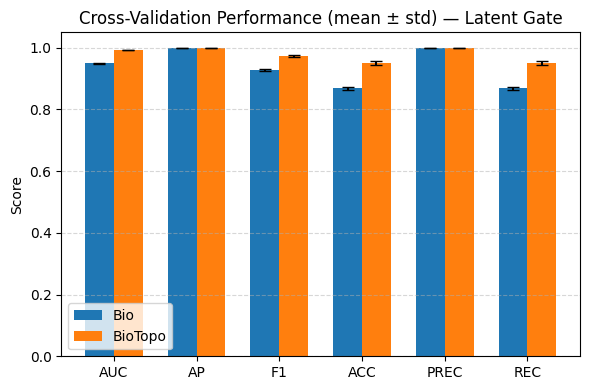

In [6]:
# Cell 5: plot bars (mean ± std across repeats)
plot_metric_bars(
    out_gate["summary"],
    model_labels=("Bio", "BioTopo"),
    metrics=("AUC", "AP", "F1", "ACC", "PREC", "REC"),
    title="Cross-Validation Performance (mean ± std) — Latent Gate"
)
plt.show()